---
>「難問はそれを解くのに適切かつ必要なところまで分割せよ。」\
>デカルト
---

# セグメンテーション



## セグメンテーションとは何か

セグメンテーションとは、画像や動画などのデータを複数のセグメント(対象領域)に分割する技術の総称であり、セグメンテーションには、セマンティックセグメンテーションやインスタンスセグメンテーションなどの種類がある

- セマンティックセグメンテーション(Semantic Segmentation)  
セマンティックセグメンテーションとは、画像を意味のある単位に分割する技術のことで、同じカテゴリーに属するピクセルをまとめて一つのセグメントとして分割する  
例えば、車や人、植物などのカテゴリーに分割することができる

- インスタンスセグメンテーション(Instance Segmentation)  
インスタンスセグメンテーションとは、画像を意味のある単位かつ個別のインスタンスに分割する技術のことで、画像内の個々の車や人、植物をそれぞれ別々のセグメントとして分割する  
例えば、同じ車種でも色や形が異なる車をそれぞれ別々に分割することができる

これまでに学んだ、画像認識、物体検出との違いも含めて説明すると次の図のようになる

<img src="http://class.west.sd.keio.ac.jp/dataai/text/segmentation.png" width=600>

また、次のような分類も存在する
- パノプティック・セグメンテーション(Panoptic Segmentation)  
セマンティック・セグメンテーションとインスタンス・セグメンテーションが組み合わさった手法とされており、画像のすべてのピクセルをクラス分類(セマンティック)し、かつ、すべてのクラスを個別に分類(インスタンス)する  
同一クラスの物体を個別に分類することと、背景などを含めた画像全体をピクセル単位で分類することを意味するが、インスタンスセグメンテーションについて、マルチクラスを想定する場合もあるため、明確に違うセグメンテーション手法と定義しない場合もある  

セグメンテーションは、画像や動画を分析するための基礎技術として認知されており、セマンティックセグメンテーションを用いて、オンラインショップの商品画像から自動的に商品カテゴリーを抽出し、分析する、医療画像から病巣を特定するなど、またインスタンスセグメンテーションを用いて、自動運転車のための道路標識の認識や障害物の検出などに応用されている


## セマンティックセグメンテーションとインスタンスセグメンテーションの違い

セマンティックセグメンテーションとインスタンスセグメンテーションでは、分割される対象が異なる

- セマンティックセグメンテーションでは、画像内の同じカテゴリーのピクセルをまとめて一つのセグメントとして分割する

- インスタンスセグメンテーションでは、画像内の個々のオブジェクトをそれぞれ別々のセグメントとして分割する




セグメンテーションの精度向上方法
セグメンテーション技術の精度向上に向けた研究開発には、様々な取り組みがされている

その一例としては、以下のようなものが挙げられる

1. データセットの拡充
セグメンテーション技術は、学習データの量や品質に大きく依存するため、大規模なデータセットを用いた学習が必要である　そのため、最近では、大規模なデータセットを構築することが注目されており、より高い精度のセグメンテーション技術の開発につながっている
2. ニューラルネットワークの改良
セグメンテーション技術は、主にディープラーニングを用いたニューラルネットワークによって実現される　そのため、ニューラルネットワークの改良によって、より高い精度のセグメンテーション技術を実現することが期待されている
3. パフォーマンスの評価指標の検討
セグメンテーション技術の評価には、IoU（Intersection over Union）や mIoU（mean Intersection over Union）などの評価指標が用いられる　しかし、これらの評価指標には課題があり、より適切な評価指標の検討が求められている
これらの取り組みが進められることによって、より高い精度のセグメンテーション技術が開発され、ビジネスの現場での応用がさらに進むことが期待されている

セグメンテーションの課題と今後の展望
セグメンテーション技術には、精度の向上や高速化などの課題がある　特に、セマンティックセグメンテーションでは、分類カテゴリーの数や分類精度によっては、高度な分類が困難な場合がある　一方で、インスタンスセグメンテーションでは、オブジェクトの形状やサイズの多様性に対応することが難しい場合もある　今後の展望としては、より高精度で高速なセグメンテーション技術の開発が期待されている

## セグメンテーションで用いるモデル


### FCN

<img src="http://class.west.sd.keio.ac.jp/dataai/text/segfcn.jpg" width=600>

FCN (Fully Convolutional Network)は、畳み込み層とプーリング層で構成される(全結合層を持たない)アーキテクチャであり、入力画像サイズを自由に設定できるというメリットがある
- したがって、任意のサイズの入力画像からセマンティックセグメンテーションを行うことができる
- 畳み込みを行って得た特徴マップをヒートマップ化(下記で説明)し、さらに逆畳込みすることによって、アップサンプリングして予測する
- アップサンプリングで単純に入力画像と同サイズに拡大すると、物体の境界がぼやけるため、最終層の特徴マップから順にアップサンプリングで前の層と同サイズに拡大し(convとpoolで小さくした手順の逆で順に大きくする)、チャンネルごとに足し算を行うことでアップサンプリングしている(特徴マップの利用)  
次の図のように、徐々にアップサンプリングすることで、境界を明瞭にしている  
<img src="http://class.west.sd.keio.ac.jp/dataai/text/fcnmap.jpg" width=600>

FCNの欠点

- フィルターサイズにより、大きさがマッチしない(特に大きい)対象物についてはうまく認識・分類ができない場合がある

#### ヒートマップ
ヒートマップとは、画素ごとにセグメンテーション結果を可視化した画像のこと

FCNでは、一般的な物体認識用のCNN網(例えばVGG-16)の全結合層を、Global Average Poolingと1x1 Convolutionに置き換えることによって、クラス分類の結果を下図のような2次元のヒートマップとして出力するように拡張した手法

<img src="http://class.west.sd.keio.ac.jp/dataai/text/segfcnhm.jpg" width=600>


#### 逆畳み込み(Deconvolution)
プーリングによって出力されるヒートマップは小さくなるため、小さい画像のアップサンプリングが必要であるが、この際に使用されるのが逆畳み込み(Deconvolution)である
- 畳み込み(convolution)の逆プロセスではないことに注意

誤解を生まないようup convolution・transposed convolutionなどとも呼ばれている

逆畳み込みのパラメータには、kernel size・padding・stride + pixel数があり、特徴マップの各pixelをstrideで指定したpixel数ずつ空けて配置したのち、kernel size-1だけ特徴マップの周囲に余白を取り、最後に、paddingで指定されたpixel数だけ余白を削るという処理が行われる

<img src="http://class.west.sd.keio.ac.jp/dataai/text/fcntconv.jpg" width=600>


### SegNet
SegNetは、ConvolutionalなEncoder(エンコーダー)とDecoder(デコーダー)で構成され、FCNよりも多くの特徴マップを利用することで性能向上を試みているが、メモリ効率が低下するため、エンコーダーの特徴をコピーせず、Maxプーリングからのインデックスをコピーすることでメモリ効率を上げている

Convolutional EncoderとDecoderの直列構造は広く使用されているモデルである

<img src="http://class.west.sd.keio.ac.jp/dataai/text/segnetconv.jpg" width=600>

- Encoderは次元を圧縮(ダウンサンプリング)により入力画像から特徴マップを抽出する
- Decoderはその抽出した特徴マップを元の次元復元(アップサンプリング)し、特徴マップと元画像のピクセル位置の対応関係をマッピングしていく

Encoderでは、プーリング層によりmax-pooling indexとして大まかな位置を記憶しておき、Decoderで、特徴マップをそのindex位置にアップサンプリングし、逆畳込みを行う(逆poolingやunpoolingとも呼ばれる)

<img src="http://class.west.sd.keio.ac.jp/dataai/text/segnetpool.jpg" width=600>

SegNetの欠点

EncoderとDecoderが直列に接続されており、特徴が伝搬する過程でピクセルの詳細な情報が失われ、結果が粗くなりやすい



### U-Net

U-Netは、畳み込み層とプーリング層で構成され、データセットに含まれる画像数が少ない場合でも、比較的セグメンテーションの精度が良いモデルで、学習および学習後の処理が低遅延であるという特長がある

ネットワークの形がU字型に見えるので、U-Netと呼ばれる

U-Netではスキップ接続が用いられており、Encoderの各層で出力される特徴マップをDecoderの対応する各層の特徴マップに連結 (concatenation)することで、小さくなった特徴マップでもDecoderに直接連結することで情報の損失をなるべく抑制している
- Encoderではpadding=0の畳み込みを行って特徴マップが少しずつ小さくなっているため、 Encoderの特徴マップの中央部分を切り出して、Decoderの特徴マップとサイズを一致させて連結している
- Encoderで出力された特徴マップを、別チャンネルとしてDecoderの特徴マップに追加する形で連結している

<img src="http://class.west.sd.keio.ac.jp/dataai/text/segunet.jpg" width=800>

# セマンティックセグメンテーション(semantic segmentation)

ここでは、U-Netに基づく手法でバイナリー・セマンティック・セグメンテーションを行う

[The Oxford-IIIT Pet Dataset
](https://www.robots.ox.ac.uk/~vgg/data/pets/)を用いて、入力画像の各ピクセルを`ペット`か`背景`のどちらかに分類する

## 環境の構築

### イメージの取得

ノートブックで使用する画像をダウンロードし、Colab環境の`images`フォルダに保存する

In [1]:
!wget -q https://github.com/albumentations-team/albumentations_examples/archive/master.zip -O /tmp/albumentations_examples.zip
!unzip -o -qq /tmp/albumentations_examples.zip -d /tmp/albumentations_examples
!cp -r /tmp/albumentations_examples/albumentations_examples-master/notebooks/images .
!echo "Images are successfully downloaded"

cp: cannot stat '/tmp/albumentations_examples/albumentations_examples-master/notebooks/images': No such file or directory
Images are successfully downloaded


Albumentationsをインストールし、各種画像に対する前処理のヘルパーとして利用するが、実際のところ新しいバージョンではresizeやcropといった基本操作が当初と別の記述になっているため、cv2に置き換えて利用している
- torchvisionを用いる例が多いかもしれない

In [2]:
!pip install -q -U albumentations
!echo "$(pip freeze | grep albumentations) is successfully installed"

albumentations==2.0.8 is successfully installed


### ライブラリの導入

ここでは、[TernausNet](https://github.com/ternaus/TernausNet)を使用する
- このライブラリは、意味分割タスクのために事前に学習された[UNet](https://en.wikipedia.org/wiki/U-Net)モデルである

In [3]:
!pip install ternausnet

その他、以下のライブラリを用いる

In [5]:
from collections import defaultdict
import copy
import random
import os
import shutil
from urllib.request import urlretrieve

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import matplotlib.pyplot as plt
import numpy as np
import ternausnet.models
from tqdm import tqdm
import torch
import torch.backends.cudnn as cudnn
import torch.nn as nn
import torch.optim
from torch.utils.data import Dataset, DataLoader

cudnn.benchmark = True

## データセットの準備

*アーカイブされたデータセットをダウンロードし、解凍する関数を定義する*

In [6]:
class TqdmUpTo(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)


def download_url(url, filepath):
    directory = os.path.dirname(os.path.abspath(filepath))
    os.makedirs(directory, exist_ok=True)
    if os.path.exists(filepath):
        print("Dataset already exists on the disk. Skipping download.")
        return

    with TqdmUpTo(unit="B", unit_scale=True, unit_divisor=1024, miniters=1, desc=os.path.basename(filepath)) as t:
        urlretrieve(url, filename=filepath, reporthook=t.update_to, data=None)
        t.total = t.n


def extract_archive(filepath):
    extract_dir = os.path.dirname(os.path.abspath(filepath))
    shutil.unpack_archive(filepath, extract_dir)

ダウンロードしたデータセットのルートディレクトリを設定

In [7]:
dataset_directory = os.path.join(os.environ["HOME"], "datasets/oxford-iiit-pet")

犬猫データセットをダウンロードして展開する
- 名誉のために言っておけば、日本語は犬猫であるが、英語は'Cats vs. Dogs'である


In [8]:
filepath = os.path.join(dataset_directory, "images.tar.gz")
download_url(
    url="https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz", filepath=filepath,
)
extract_archive(filepath)

images.tar.gz: 100%|██████████| 755M/755M [00:32<00:00, 24.5MB/s]


In [9]:
filepath = os.path.join(dataset_directory, "annotations.tar.gz")
download_url(
    url="https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz", filepath=filepath,
)
extract_archive(filepath)

annotations.tar.gz: 100%|██████████| 18.3M/18.3M [00:03<00:00, 5.98MB/s]


### データセットの分割

データセットを訓練セットと検証セットに分割する
- データセットの中には壊れているファイルもあるので、OpenCVが正しく読み込めた画像ファイルのみを使用
- トレーニングには6000枚、検証には1374枚、テストには10枚の画像を使用

In [10]:
root_directory = os.path.join(dataset_directory)
images_directory = os.path.join(root_directory, "images")
masks_directory = os.path.join(root_directory, "annotations", "trimaps")

images_filenames = list(sorted(os.listdir(images_directory)))
correct_images_filenames = [i for i in images_filenames if cv2.imread(os.path.join(images_directory, i)) is not None]

random.seed(42)
random.shuffle(correct_images_filenames)

train_images_filenames = correct_images_filenames[:6000]
val_images_filenames = correct_images_filenames[6000:-10]
test_images_filenames = images_filenames[-10:]

print(len(train_images_filenames), len(val_images_filenames), len(test_images_filenames))

6000 1380 10


## マスク前処理関数定義

データセットにはピクセルレベルのトリマップセグメンテーションが含まれ、各画像には関連するマスク付きPNGファイルが含まれている

マスクのサイズは関連画像のサイズに等しく、マスク画像の各ピクセルは3つの値のうちの1つを取り、画像の対象となるピクセルについて、
- `1` は `pet` クラスであることを意味する
- `2` は `background` クラスであることを意味する
- `3` は `border` クラスに属することを意味する

バイナリー・セグメンテーション(各ピクセルに2つのクラスのいずれかを割り当てること)のタスクであるため、マスクを前処理し、2つのユニークな値だけを含むようにする
- ピクセルが背景であれば `0`、ペットまたはボーダーであれば `1.0` とする


In [11]:
def preprocess_mask(mask):
    mask = mask.astype(np.float32)
    mask[mask == 2.0] = 0.0
    mask[(mask == 1.0) | (mask == 3.0)] = 1.0
    return mask

### 可視化のヘルパー関数定義

画像とそのラベルを視覚化する関数を定義する

画像のファイル名のリスト、画像のあるディレクトリへのパス、マスクのあるディレクトリへのパス、そしてオプションの引数に予測マスク(後にモデルの予測値を表示するために利用)を引数とする可視化関数を定義する

In [12]:
def display_image_grid(images_filenames, images_directory, masks_directory, predicted_masks=None):
    cols = 3 if predicted_masks else 2
    rows = len(images_filenames)
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 24))
    for i, image_filename in enumerate(images_filenames):
        image = cv2.imread(os.path.join(images_directory, image_filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(os.path.join(masks_directory, image_filename.replace(".jpg", ".png")), cv2.IMREAD_UNCHANGED,)
        mask = preprocess_mask(mask)
        ax[i, 0].imshow(image)
        ax[i, 1].imshow(mask, interpolation="nearest")

        ax[i, 0].set_title("Image")
        ax[i, 1].set_title("Ground truth mask")

        ax[i, 0].set_axis_off()
        ax[i, 1].set_axis_off()

        if predicted_masks:
            predicted_mask = predicted_masks[i]
            ax[i, 2].imshow(predicted_mask, interpolation="nearest")
            ax[i, 2].set_title("Predicted mask")
            ax[i, 2].set_axis_off()
    plt.tight_layout()
    plt.show()

実際に表示すると次のようになる

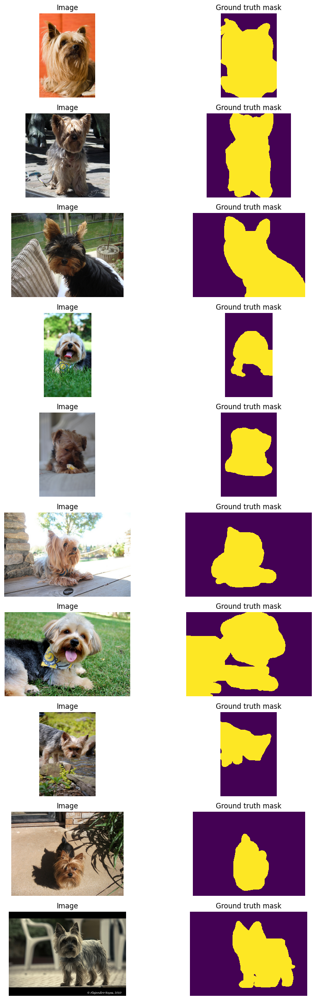

In [13]:
display_image_grid(test_images_filenames, images_directory, masks_directory)

## トレーニング用と予測用の画像サイズ

多くの場合、学習と推論に使用する画像は、高さや幅、アスペクト比が異なるが、
- 学習モデルはバッチ内のすべての画像の高さと幅が同一としてネットワークモデルへの入力サイズをそろえる必要がある
- ニューラルネットワークが完全畳み込み型(畳み込み層だけで構築されたネットワーク)でない場合、学習時と推論時にすべての画像に同じ幅と高さを使用しなければならない
- UNetのような完全畳み込みアーキテクチャは、どんなサイズの画像でも扱うことができる

そこで、次の解決法が選択肢として存在する
-  学習時にすべての画像とマスクを固定サイズにリサイズする
  - 推論中にモデルがその固定サイズのマスクを予測した後、マスクを元の画像サイズにリサイズする
  - 予測されたマスクは画像よりも小さくなり、マスクは元画像のコンテキストや重要なディテールを失う可能性がある
  - データセットの画像のアスペクト比が異なる場合、このアプローチは問題になる可能性がある
    - 例えば、サイズ1024x512ピクセルの画像を256x256ピクセルにリサイズすると画像を歪ませ、予測の品質にも影響を与える可能性がある
- 完全畳み込みニューラルネットワークを使用する場合
  - 画像を切り抜いてモデルを訓練し、推論には元の画像を使用する
  - 通常、品質、学習速度、ハードウェア要件の間でバランスの取れた良い手法といえる
- 画像のサイズを変更せず、元画像を学習と推論の両方に使用する
  - この方法では、情報を失うことはないが、元画像が大きい場合、多くのGPUメモリを必要とする可能性がある
  - 良い結果を得るために、より多くのトレーニングリソースが必要となる

UNetのようないくつかのアーキテクチャでは、画像のサイズはネットワークのダウンサンプリング係数（通常は32）で割り切れる必要があるため、画像に境界線を設ける必要がある

次の例は、異なるタイプの画像がどのように見えるかを示している

In [14]:
example_image_filename = correct_images_filenames[0]
image = cv2.imread(os.path.join(images_directory, example_image_filename))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#resized_image = F.resize(image, height=256, width=256)
resized_image = cv2.resize(image, (256,256))
#padded_image = F.pad(image, min_height=512, min_width=512)
vmer = int((512-image.shape[0])/2)+1
hmer = int((512-image.shape[1])/2)+1
padded_image = cv2.copyMakeBorder(image, vmer, vmer, hmer, hmer, cv2.BORDER_CONSTANT)
#padded_constant_image = F.pad(image, min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT)
padded_constant_image = cv2.copyMakeBorder(image, vmer, vmer, hmer, hmer, cv2.BORDER_CONSTANT)
#cropped_image = F.center_crop(image, crop_height=256, crop_width=256)
vcrp = int((image.shape[0]-256)/2)
hcrp = int((image.shape[1]-256)/2)
cropped_image = image[vcrp:vcrp+256, hcrp:hcrp+256]

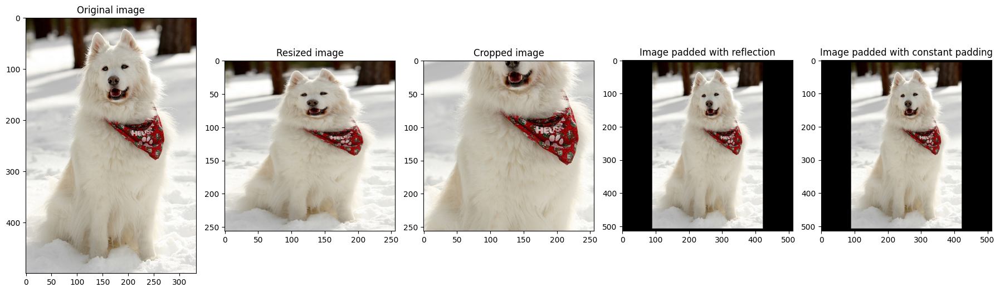

In [15]:
figure, ax = plt.subplots(nrows=1, ncols=5, figsize=(18, 10))
ax.ravel()[0].imshow(image)
ax.ravel()[0].set_title("Original image")
ax.ravel()[1].imshow(resized_image)
ax.ravel()[1].set_title("Resized image")
ax.ravel()[2].imshow(cropped_image)
ax.ravel()[2].set_title("Cropped image")
ax.ravel()[3].imshow(padded_image)
ax.ravel()[3].set_title("Image padded with reflection")
ax.ravel()[4].imshow(padded_constant_image)
ax.ravel()[4].set_title("Image padded with constant padding")
plt.tight_layout()
plt.show()

ここでは、画像サイズを扱うための3つのアプローチすべてを扱って評価する

## 手法1 固定サイズに変更

すべての画像とマスクのサイズを固定サイズ(例えば256x256ピクセル)に変更する


### PyTorchデータセットクラスを定義する

`__init__`はオプションの引数 `transform` を受け取る
- Albumentations augmentation pipelineの変換関数である
-  `__getitem__` で、 Dataset クラスはその関数を使用して画像とマスクを拡張する

In [16]:
class OxfordPetDataset(Dataset):
    def __init__(self, images_filenames, images_directory, masks_directory, transform=None):
        self.images_filenames = images_filenames
        self.images_directory = images_directory
        self.masks_directory = masks_directory
        self.transform = transform

    def __len__(self):
        return len(self.images_filenames)

    def __getitem__(self, idx):
        image_filename = self.images_filenames[idx]
        image = cv2.imread(os.path.join(self.images_directory, image_filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(
            os.path.join(self.masks_directory, image_filename.replace(".jpg", ".png")), cv2.IMREAD_UNCHANGED,
        )
        mask = preprocess_mask(mask)
        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
        return image, mask

次に、トレーニングデータセットと検証データセットのオーグメンテーションパイプラインを作成する

`A.Resize(256,256)`を使って、入力画像とマスクのサイズを256x256ピクセルにリサイズする

In [17]:
train_transform = A.Compose(
    [
        A.Resize(256, 256),
        A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0.2, rotate_limit=30, p=0.5),
        A.RGBShift(r_shift_limit=25, g_shift_limit=25, b_shift_limit=25, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)
train_dataset = OxfordPetDataset(train_images_filenames, images_directory, masks_directory, transform=train_transform,)

val_transform = A.Compose(
    [A.Resize(256, 256), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]
)
val_dataset = OxfordPetDataset(val_images_filenames, images_directory, masks_directory, transform=val_transform,)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


データセットを受け取り、同じ画像と関連するマスクに適用されたさまざまな拡張(Augmentation)を視覚化する関数を定義する

In [18]:
def visualize_augmentations(dataset, idx=0, samples=5):
    dataset = copy.deepcopy(dataset)
    dataset.transform = A.Compose([t for t in dataset.transform if not isinstance(t, (A.Normalize, ToTensorV2))])
    figure, ax = plt.subplots(nrows=samples, ncols=2, figsize=(10, 24))
    for i in range(samples):
        image, mask = dataset[idx]
        ax[i, 0].imshow(image)
        ax[i, 1].imshow(mask, interpolation="nearest")
        ax[i, 0].set_title("Augmented image")
        ax[i, 1].set_title("Augmented mask")
        ax[i, 0].set_axis_off()
        ax[i, 1].set_axis_off()
    plt.tight_layout()
    plt.show()

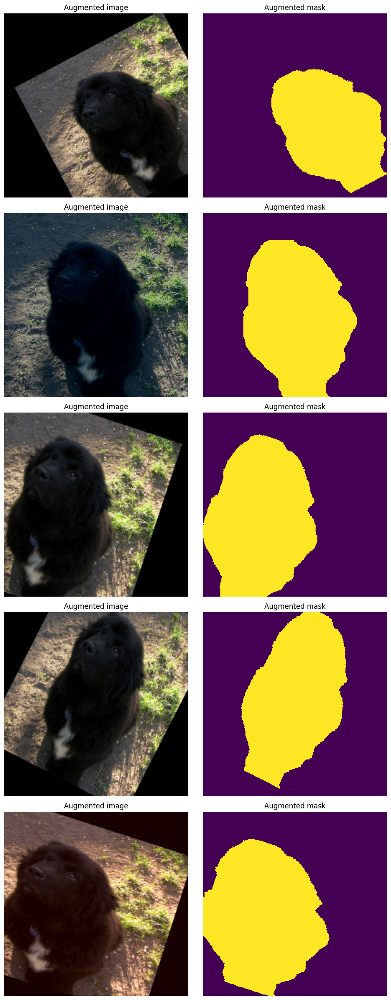

In [19]:
random.seed(42)
visualize_augmentations(train_dataset, idx=55)

### トレーニングヘルパーの定義

`MetricMonitor`は、トレーニングや検証中の精度や損失などのメトリクスを追跡する

In [20]:
class MetricMonitor:
    def __init__(self, float_precision=3):
        self.float_precision = float_precision
        self.reset()

    def reset(self):
        self.metrics = defaultdict(lambda: {"val": 0, "count": 0, "avg": 0})

    def update(self, metric_name, val):
        metric = self.metrics[metric_name]

        metric["val"] += val
        metric["count"] += 1
        metric["avg"] = metric["val"] / metric["count"]

    def __str__(self):
        return " | ".join(
            [
                "{metric_name}: {avg:.{float_precision}f}".format(
                    metric_name=metric_name, avg=metric["avg"], float_precision=self.float_precision
                )
                for (metric_name, metric) in self.metrics.items()
            ]
        )

### 訓練・検証用関数定義


In [21]:
def train(train_loader, model, criterion, optimizer, epoch, params):
    metric_monitor = MetricMonitor()
    model.train()
    stream = tqdm(train_loader)
    for i, (images, target) in enumerate(stream, start=1):
        images = images.to(params["device"], non_blocking=True)
        target = target.to(params["device"], non_blocking=True)
        output = model(images).squeeze(1)
        loss = criterion(output, target)
        metric_monitor.update("Loss", loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        stream.set_description(
            "Epoch: {epoch}. Train.      {metric_monitor}".format(epoch=epoch, metric_monitor=metric_monitor)
        )

In [22]:
def validate(val_loader, model, criterion, epoch, params):
    metric_monitor = MetricMonitor()
    model.eval()
    stream = tqdm(val_loader)
    with torch.no_grad():
        for i, (images, target) in enumerate(stream, start=1):
            images = images.to(params["device"], non_blocking=True)
            target = target.to(params["device"], non_blocking=True)
            output = model(images).squeeze(1)
            loss = criterion(output, target)
            metric_monitor.update("Loss", loss.item())
            stream.set_description(
                "Epoch: {epoch}. Validation. {metric_monitor}".format(epoch=epoch, metric_monitor=metric_monitor)
            )

In [23]:
def create_model(params):
    model = getattr(ternausnet.models, params["model"])(pretrained=True)
    model = model.to(params["device"])
    return model

In [24]:
def train_and_validate(model, train_dataset, val_dataset, params):
    train_loader = DataLoader(
        train_dataset,
        batch_size=params["batch_size"],
        shuffle=True,
        num_workers=params["num_workers"],
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=params["batch_size"],
        shuffle=False,
        num_workers=params["num_workers"],
        pin_memory=True,
    )
    criterion = nn.BCEWithLogitsLoss().to(params["device"])
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    for epoch in range(1, params["epochs"] + 1):
        train(train_loader, model, criterion, optimizer, epoch, params)
        validate(val_loader, model, criterion, epoch, params)
    return model

In [25]:
def predict(model, params, test_dataset, batch_size):
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=params["num_workers"], pin_memory=True,
    )
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, (original_heights, original_widths) in test_loader:
            images = images.to(params["device"], non_blocking=True)
            output = model(images)
            probabilities = torch.sigmoid(output.squeeze(1))
            predicted_masks = (probabilities >= 0.5).float() * 1
            predicted_masks = predicted_masks.cpu().numpy()
            for predicted_mask, original_height, original_width in zip(
                predicted_masks, original_heights.numpy(), original_widths.numpy()
            ):
                predictions.append((predicted_mask, original_height, original_width))
    return predictions

### トレーニングパラメーターの定義

ここでは、モデル・アーキテクチャ、学習率、バッチ・サイズ、エポック数など、いくつかの学習パラメータを定義する

In [26]:
params = {
    "model": "UNet11",
    "device": "cuda",
    "lr": 0.001,
    "batch_size": 16,
    "num_workers": 4,
    "epochs": 10,
}

### モデルの訓練

実行には30分程度必要である
- 10エポック実行する

In [27]:
model = create_model(params)
model = train_and_validate(model, train_dataset, val_dataset, params)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg11-8a719046.pth" to /root/.cache/torch/hub/checkpoints/vgg11-8a719046.pth


100%|██████████| 507M/507M [00:02<00:00, 178MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  0%|          | 0/375 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if neces

画像のラベルを予測し、その予測を視覚化するため、いくつかの画像のマスクを予測する
- `__getitem__`メソッドは画像だけでなく、画像の元の高さと幅も返すため、予測されたマスクを256x256ピクセルのサイズから元の画像のサイズにリサイズする

In [28]:
class OxfordPetInferenceDataset(Dataset):
    def __init__(self, images_filenames, images_directory, transform=None):
        self.images_filenames = images_filenames
        self.images_directory = images_directory
        self.transform = transform

    def __len__(self):
        return len(self.images_filenames)

    def __getitem__(self, idx):
        image_filename = self.images_filenames[idx]
        image = cv2.imread(os.path.join(self.images_directory, image_filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_size = tuple(image.shape[:2])
        if self.transform is not None:
            transformed = self.transform(image=image)
            image = transformed["image"]
        return image, original_size

In [29]:
test_transform = A.Compose(
    [A.Resize(256, 256), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]
)
test_dataset = OxfordPetInferenceDataset(test_images_filenames, images_directory, transform=test_transform,)

In [30]:
predictions = predict(model, params, test_dataset, batch_size=16)

次に、256x256ピクセルのサイズで予測されたマスクを元の画像のサイズにリサイズする

In [31]:
predicted_masks = []
for predicted_256x256_mask, original_height, original_width in predictions:
    #full_sized_mask = F.resize(predicted_256x256_mask, height=original_height, width=original_width, interpolation=cv2.INTER_NEAREST)
    full_sized_mask = cv2.resize(predicted_256x256_mask, (original_width,original_height))
    predicted_masks.append(full_sized_mask)

確認してみよう
- 影などとの融合が気になるが、悪くはない

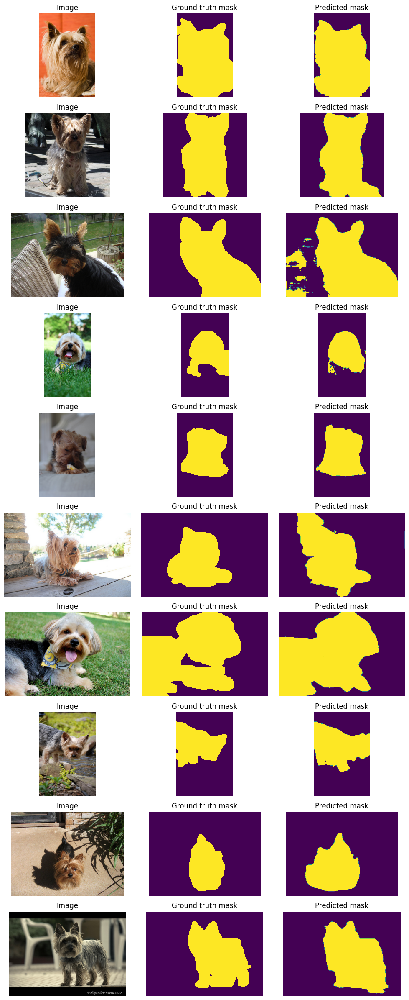

In [32]:
display_image_grid(test_images_filenames, images_directory, masks_directory, predicted_masks=predicted_masks)

## 手法2 クロップ

クロップ画像で学習し、フルサイズ画像のマスクを予測する

前の例のコードの多くを再利用する

データセット画像の高さと幅は、クロップサイズ(256x256ピクセル)より小さい場合があるため、画像の高さと幅が256ピクセルより小さい場合に画像をpaddingする

In [33]:
train_transform = A.Compose(
    [
        A.PadIfNeeded(min_height=256, min_width=256),
        A.RandomCrop(256, 256),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)
train_dataset = OxfordPetDataset(train_images_filenames, images_directory, masks_directory, transform=train_transform,)

In [34]:
val_transform = A.Compose(
    [
        A.PadIfNeeded(min_height=256, min_width=256),
        A.CenterCrop(256, 256),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)
val_dataset = OxfordPetDataset(val_images_filenames, images_directory, masks_directory, transform=val_transform,)

In [35]:
params = {
    "model": "UNet11",
    "device": "cuda",
    "lr": 0.001,
    "batch_size": 16,
    "num_workers": 4,
    "epochs": 10,
}

やはり実行には30分程度必要である

In [36]:
model = create_model(params)
model = train_and_validate(model, train_dataset, val_dataset, params)

Epoch: 10. Validation. Loss: 0.153: 100%|██████████| 87/87 [00:13<00:00,  6.39it/s]


テストデータセットの画像はすべて最大辺が500ピクセルである

バッチ内のすべての画像のサイズが同じである必要があり、また、UNetは画像のサイズが16で割り切れることを要求しているので、 `A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT)` を適用する
- この拡張は画像の境界を0で埋めるため、画像サイズは512x512ピクセルになる

In [37]:
test_transform = A.Compose(
    [
        A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT, value=0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)
test_dataset = OxfordPetInferenceDataset(test_images_filenames, images_directory, transform=test_transform,)

/tmp/ipykernel_8704/2569281184.py:3: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT, value=0),


In [38]:
predictions = predict(model, params, test_dataset, batch_size=16)

パディングされた画像用のマスクを受け取ったので、パディングされたマスクから元の画像サイズの一部を切り取る


In [39]:
predicted_masks = []
for predicted_padded_mask, original_height, original_width in predictions:
    #cropped_mask = F.center_crop(predicted_padded_mask, original_height, original_width)
    vcrp = int((predicted_padded_mask.shape[0]-original_height)/2)
    hcrp = int((predicted_padded_mask.shape[1]-original_width)/2)
    cropped_mask = predicted_padded_mask[vcrp:vcrp+original_height, hcrp:hcrp+original_width]
    predicted_masks.append(cropped_mask)

確認してみよう
- 影や周辺物体との融合が気になるが、それほどおかしい分類はしていない

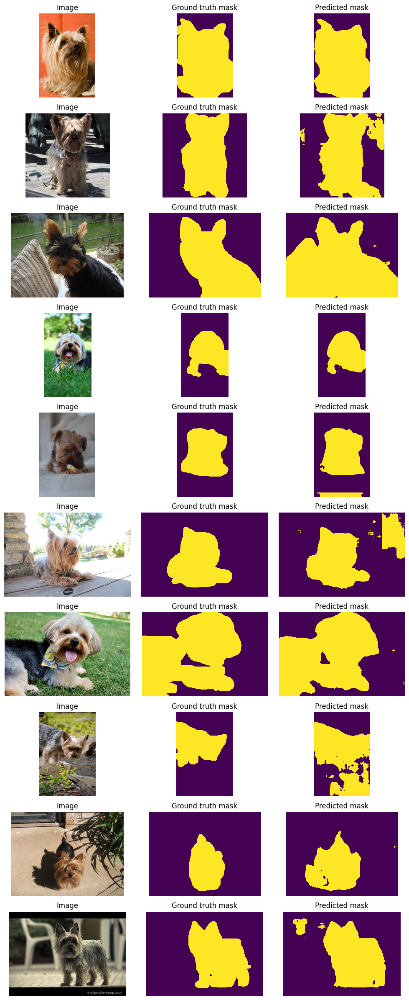

In [40]:
display_image_grid(test_images_filenames, images_directory, masks_directory, predicted_masks=predicted_masks)

## 手法3 オリジナル画像の利用(実行する意味はない)

**実行に2時間30分必要であり、精度が悪いという結果になるため、特に実行しなくともよい**

リサイズやトリミングをせずにオリジナルの画像を使う

データセットのいくつかの画像は非常に大きく、`batch_size=1`であっても、学習に11Gb以上のGPUメモリを必要とするため、やむなく画像の最大サイズが512ピクセル以下になるように`A.LongestMaxSize(512)`オーグメントを適用する
- この拡張は7384枚のデータセットの画像のうち137枚だけに影響する

その後、`A.PadIfNeeded(min_height=512, min_width=512)` を使って、バッチ内のすべての画像のサイズが512x512ピクセルになるようにする

In [41]:
train_transform = A.Compose(
    [
        A.LongestMaxSize(512),
        A.PadIfNeeded(min_height=512, min_width=512),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)
train_dataset = OxfordPetDataset(train_images_filenames, images_directory, masks_directory, transform=train_transform,)

val_transform = A.Compose(
    [
        A.LongestMaxSize(512),
        A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT, value=0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)
val_dataset = OxfordPetDataset(val_images_filenames, images_directory, masks_directory, transform=val_transform,)

/tmp/ipykernel_8704/393538551.py:17: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT, value=0),


In [42]:
params = {
    "model": "UNet11",
    "device": "cuda",
    "lr": 0.001,
    "batch_size": 8,
    "num_workers": 4,
    "epochs": 10,
}

この手法は計算コストが大きく、2時間30分程度必要である
- 従って、特に実行する必要はない

In [43]:
model = create_model(params)
model = train_and_validate(model, train_dataset, val_dataset, params)

Epoch: 10. Validation. Loss: 0.115: 100%|██████████| 173/173 [01:04<00:00,  2.70it/s]


先ほどと同じコードを使って予測を行う

In [44]:
test_transform = A.Compose(
    [
        A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT, value=0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)
test_dataset = OxfordPetInferenceDataset(test_images_filenames, images_directory, transform=test_transform,)

/tmp/ipykernel_8704/2569281184.py:3: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT, value=0),


In [45]:
predictions = predict(model, params, test_dataset, batch_size=16)

In [46]:
predicted_masks = []
for predicted_padded_mask, original_height, original_width in predictions:
   #cropped_mask = F.center_crop(predicted_padded_mask, original_height, original_width)
    vcrp = int((predicted_padded_mask.shape[0]-original_height)/2)
    hcrp = int((predicted_padded_mask.shape[1]-original_width)/2)
    cropped_mask = predicted_padded_mask[vcrp:vcrp+original_height, hcrp:hcrp+original_width]
    predicted_masks.append(cropped_mask)

確認してみよう
- 品質が落ちており、学習時間に見合っていないといえる

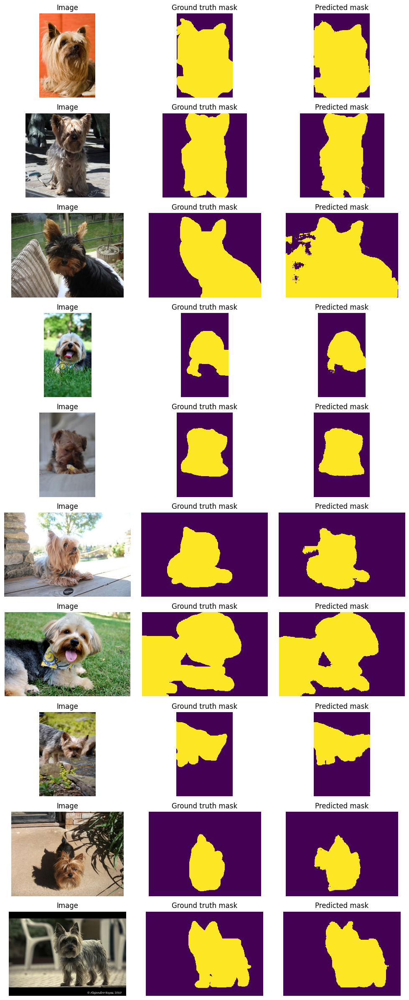

In [47]:
display_image_grid(test_images_filenames, images_directory, masks_directory, predicted_masks=predicted_masks)

# 課題1

トレーニングデータセットを用いて、背景かどうかのバイナリセグメンテーションの動作を、確認しなさい




# 課題2

トレーニングデータセットを用いて、マルチクラスのセグメンテーションに拡張して動作を確認しなさい

# チェックポイント

必要に応じて一度ここで中断し、次のセルから再度実行すること

In [48]:
#from google.colab import runtime
#runtime.unassign()

# Segment Anythingによるゼロショットセグメンテーション

# Segment Anythingについて

Segment Anything（SA）は、画像のセグメンテーション(画像の部分ごとの分割)モデル、データセットを含む統合環境であり、データ収集ループで使用することにより、11Mのライセンスされた画像に対して10億枚以上のマスクが付与されたデータセットを利用している
- モデルはプロンプトに対応するように設計・学習されており、新しい画像の分布やタスクに対してゼロショット(事前学習のみ)で適応できる
- Segment Anything Model(SAM)と、1Bのマスクと11Mの画像が含まれるデータセット(SA-1B)が提供されており、コンピュータビジョンの基盤モデルとしても利用できる


## Segment Anything Model

Segment Anything Model (SAM) は、特定したいオブジェクトを示すプロンプトが与えられると、そのオブジェクトのマスクを予測するモデルである

SAMのアーキテクチャは大きく次の3つの部分に分けられる

- Image encoder
  - ViTをベースとしたMAEが使用されている　MAE(Masked Autoencoder)が用いられており、入力画像の75%をマスクした状態で特徴量をエンコードしている
  - デコードの際にマスク部分を補完するよう学習することで精度を上げることができる

- Prompt encoder
  - プロンプトは、ポイント、ボックス、テキストの疎入力と、マスクの密入力の2つのセットで考える
  - ポイントとボックスは位置エンコーディングで表現する
  - プロンプトタイプごとに学習した画像埋め込みと合計する
  - 自由形式のテキストはCLIPの既製のテキストエンコーダで表現する
  - 密なプロンプト(マスク)は、畳み込みを使って埋め込まれ、画像埋め込みと要素ごとに合計される

- Mask decoder
  - 画像埋め込み、プロンプト埋め込み、および出力トークンを効率的にマスクにマッピングする
  - Transformerデコーダブロックの修正と、動的マスク予測ヘッドを採用している
  - すべての埋め込みを更新するために、プロンプトのセルフアテンションと2方向のクロスアテンション(プロンプトから画像埋め込み、またはその逆)を使用する
  - その後画像埋め込みをアップサンプリングし、CLIPの出力トークンを動的線形分類器にマッピング、各画像位置でのマスクフォアグラウンド確率を計算する

### SAM 2 (Segment Anything Model 2)

SAM 2(2024)は、Meta AIが発表したSAMの後継モデルであり、画像に加えて動画のセグメンテーションにも対応している
- Streaming Architectureを採用し、動画フレームをリアルタイムに処理できる
- Memory Attention機構により、過去のフレーム情報を効率的に参照し、時間的一貫性のあるセグメンテーションを実現している
- SA-Vデータセット(50.9Kの動画、642.6Kのマスクレット)で学習されている

## Segment Anything Data Engine

セグメンテーションマスクはインターネット上に豊富に存在しないため、1.1BのマスクデータセットSA-1Bを収集できるようにデータエンジンを構築して利用している

このデータエンジンは以下の3段階から構成される

- モデルアシストによるマニュアルアノテーションステージ（アシストマニュアルステージ）
- 自動予測マスクとモデルによるアノテーションを組み合わせたセミオートマチックステージ
- アノテータの入力なしにモデルがマスクを生成するフルオートマチックステージ

詳細は次の通り

- アシストマニュアルステージ：  
  - 第1段階では、プロのアノテータチームがSAMを搭載したブラウザベースの対話型セグメンテーションツールを利用し、フォアグラウンド/バックグラウンドのオブジェクトポイントをクリックしてマスクにラベル付けする
  - マスクは、ピクセル単位の「ブラシ」と「消しゴム」ツールでファインチューニングする
  - モデルアシスト型アノテーションは、ブラウザ上で直接リアルタイムに実行される(事前に計算された画像埋め込みを使用)
  - オブジェクトのラベル付けには意味的な制約を設けず、アノテータは「もの」と「こと」の両方に自由にラベル付けを行う
  - アノテータは目立つものから順にラベルを付けており、1つのマスクのアノテーションに30秒以上かかる場合は次の画像に進むように処理された
  - この段階では一般的な公開セグメンテーションデータセットを用いてSAMを訓練させている
    - 十分なデータアノテーションを行った後、新たにアノテーションされたマスクのみを用いてSAMを再訓練している
    - 途中モデルを拡張しつつ6回モデルの再訓練を行った
    - SAMの改良に伴い画像1枚あたりの平均マスク数は20枚から44枚に増加
- セミオートマチックステージ：
  - この段階ではマスクの多様性を高めることで、あらゆるものをセグメンテーションするモデルの能力を向上させるようにしている
  - 目立たない対象物にアノテーションを集中させるため、自信のあるマスクを自動的に検出する
  - これらのマスクをあらかじめ塗りつぶした画像をアノテーション担当者に提示し、アノテーションされていないオブジェクトがあれば追加でアノテーションする
  - 確信度の高いマスクを検出するために一般的な「オブジェクト」カテゴリを使用し、すべての第1段階のマスクに対してバウンディングボックス検出器を訓練した
  - 新たに収集したデータに対して、5回モデルの再訓練を行った
- フルオートマチックステージ：
  - 最終段階では、アノテーションは完全に自動化された
  - 前ステージの多様なマスクを含め、モデルを大幅に改善するのに十分な量のマスクを収集
  - 曖昧性を意識したモデルを開発し、曖昧なケースでも有効なマスクを予測できるようにした
  - 具体的には、32x32の規則正しい格子状のポイントをモデルに促し、各ポイントに対して有効なオブジェクトに対応する可能性があるマスクの集合を予測した
  - 最後に自信のある安定したマスクを選択した後、NMS(Non-Maximal Suppression)を適用し重複をフィルタリング
  - 小さなマスクの品質をさらに向上させるために、複数の重なり合うズームイン画像の切り出しも処理

環境を構築する

In [49]:
!git clone https://github.com/facebookresearch/segment-anything.git
%cd segment-anything

Cloning into 'segment-anything'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 18.31 MiB | 22.70 MiB/s, done.
Resolving deltas: 100% (161/161), done.
/content/segment-anything


In [50]:
!pip install -e .

Obtaining file:///content/segment-anything
  Preparing metadata (setup.py) ... done
  Running setup.py develop for segment_anything


In [51]:
!pip install opencv-python pycocotools matplotlib onnxruntime onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 86.4 MB/s eta 0:00:00


テスト用の画像をダウンロードする

In [52]:
!wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
!wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/groceries.jpg
!wget -P checkpoint  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2026-03-31 19:31:37--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 271475 (265K) [image/jpeg]
Saving to: ‘images/truck.jpg’

truck.jpg           100%[===================>] 265.11K  --.-KB/s    in 0.02s   

2026-03-31 19:31:38 (16.7 MB/s) - ‘images/truck.jpg’ saved [271475/271475]

--2026-03-31 19:31:38--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/groceries.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaitin

必要なライブラリを読み込む

In [53]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

各種ヘルパー関数を準備する

In [54]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

次の部分で、`!_src.empty() in function 'cv::cvtColor'`などといったエラーが表示される場合は、単純にcv2.imreadでファイルが見つからないというエラーである
- Colorとでるが色の問題ではない
- 本来は、imreadがexceptionを生成するべきであるが、ファイル名がない場合NULLを返すという、素人のような実装
- こういう実装をしてはいけない


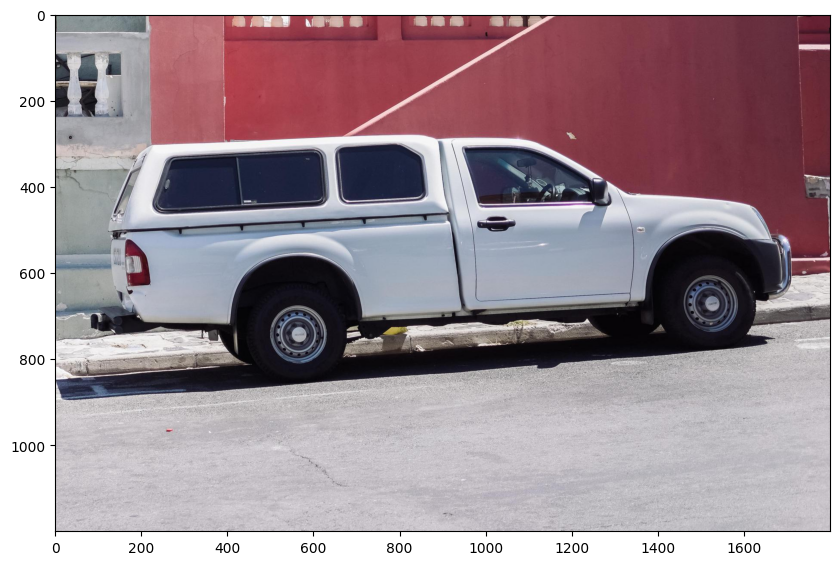

In [55]:
image = cv2.imread("images/truck.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('on')
plt.show()

まず、SAMモデルと予測器を読み込む

In [56]:
import sys
from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "checkpoint/sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)

SamPredictor.set_imageを呼び出して画像を処理し、画像埋め込みを生成する
- SamPredictorはこの埋め込みを記憶し、その後のマスク予測に利用する

In [57]:
predictor.set_image(image)

トラックを選択するには、トラック上の点を選択する　点は（x,y）形式でモデルに入力され、ラベルは1（前景点）または0（背景点）である
- 複数の点を入力できるが、ここでは1点のみを指定する

In [58]:
input_point = np.array([[500, 375]])
input_label = np.array([1])

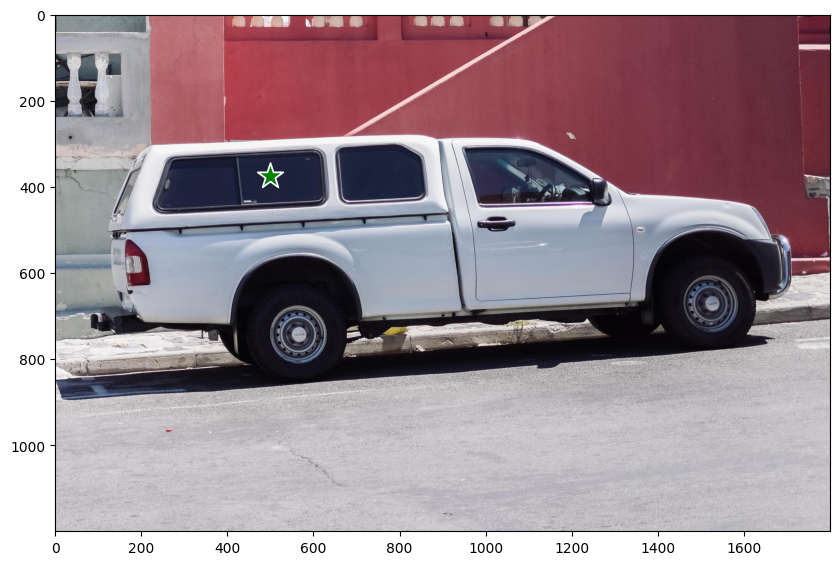

In [59]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()

SamPredictor.predictで予測する
- マスク、それらのマスクの品質予測、および次の反復予測に渡すことができる低解像度マスクのロジットを返す

In [60]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

デフォルト設定であるmultimask_output=Trueを指定すると、SAMは3つのマスクを出力し、scoresはこれらのマスクの品質をモデル自身が評価したものとなる
- この設定は曖昧な入力プロンプトに対応し、プロンプトに一貫した異なるオブジェクトを判別するのに役立つ
- Falseの場合、1つのマスクのみが返される
  - 単一の点のような曖昧なプロンプトの場合、たとえ1つのマスクだけが必要であっても、multimask_output=Trueを使用することが推奨される
- scoresで返される最も高いスコアを持つマスクを選択することで、最適な単一のマスクが選択できる
  - 結果的に、より良いマスクが得られるようになる


In [61]:
masks.shape  # (number_of_masks) x H x W

(3, 1200, 1800)

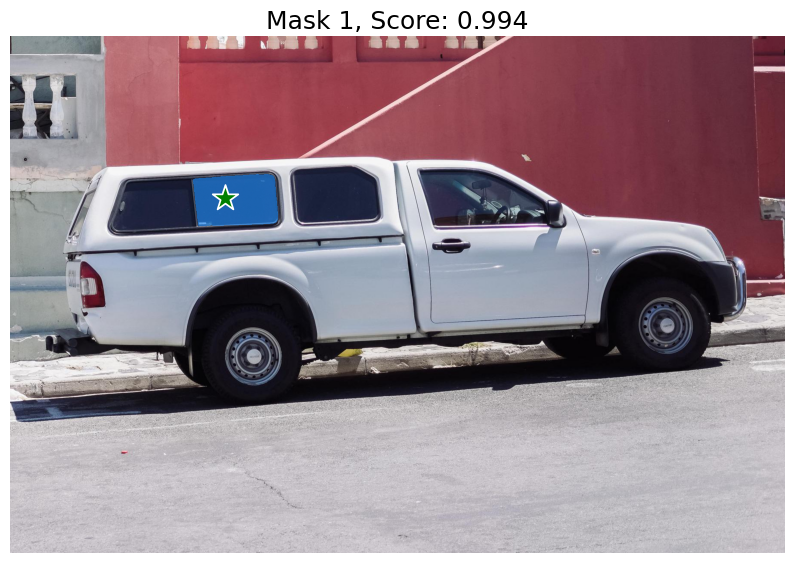

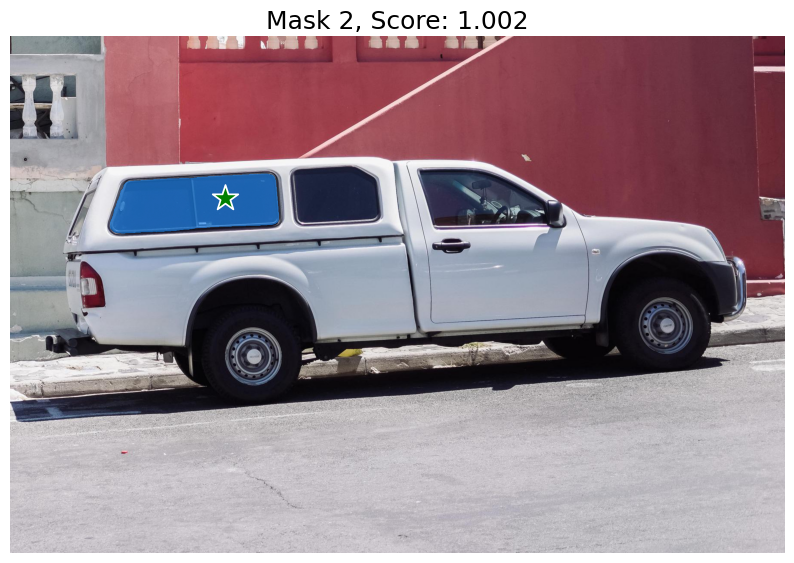

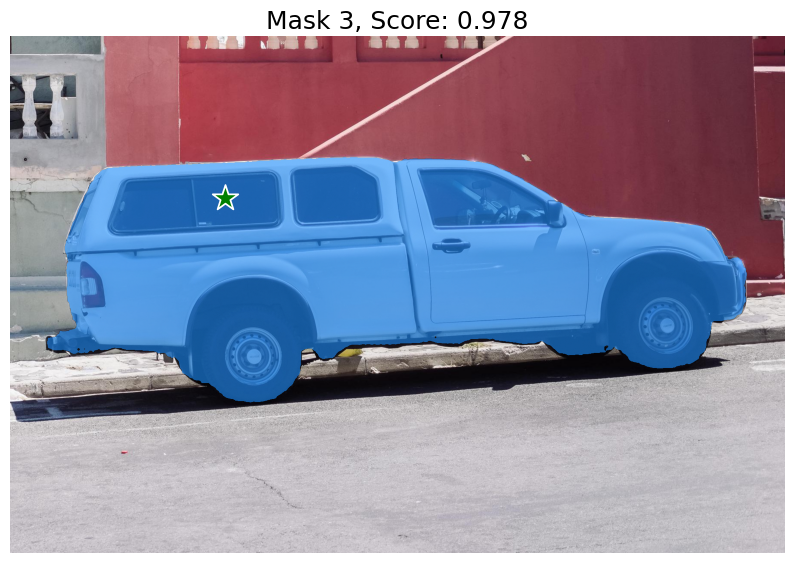

In [62]:
for i, (mask, score) in enumerate(zip(masks, scores)):
    plt.figure(figsize=(10,10))
    plt.imshow(image)
    show_mask(mask, plt.gca())
    show_points(input_point, input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.axis('off')
    plt.show()


## 特定のオブジェクトを追加の点で指定
単一の入力点が曖昧である場合、モデルはそれと一致する複数のオブジェクトを返す

これを回避するため、単一のオブジェクトの設定に対して、複数の点を入力することができる
利用可能であれば、前回試行から反復して保持しているマスクについても、予測を補助のため、モデルの入力に加えることができる
- 複数のプロンプトで単一のオブジェクトを指定する場合multimask_output=Falseを設定することで単一のマスクをリクエストできる

In [63]:
input_point = np.array([[500, 375], [1125, 625]])
input_label = np.array([1, 1])

mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

In [64]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

In [65]:
masks.shape

(1, 1200, 1800)

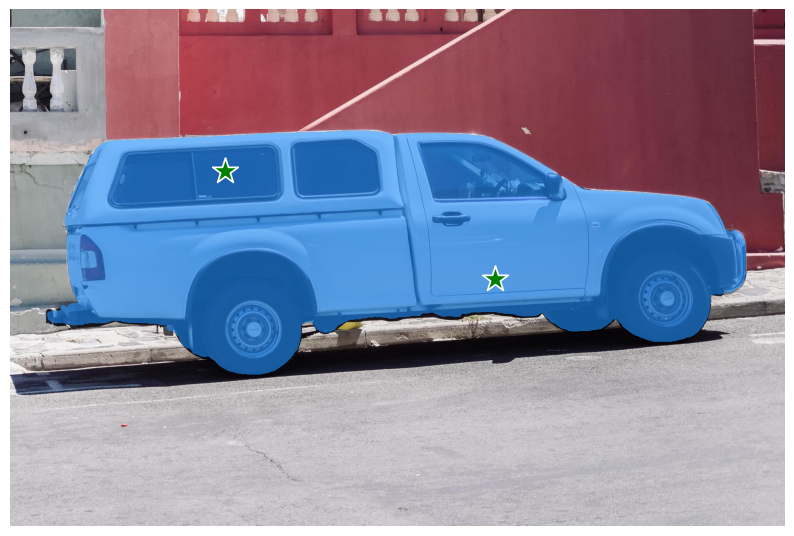

In [66]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

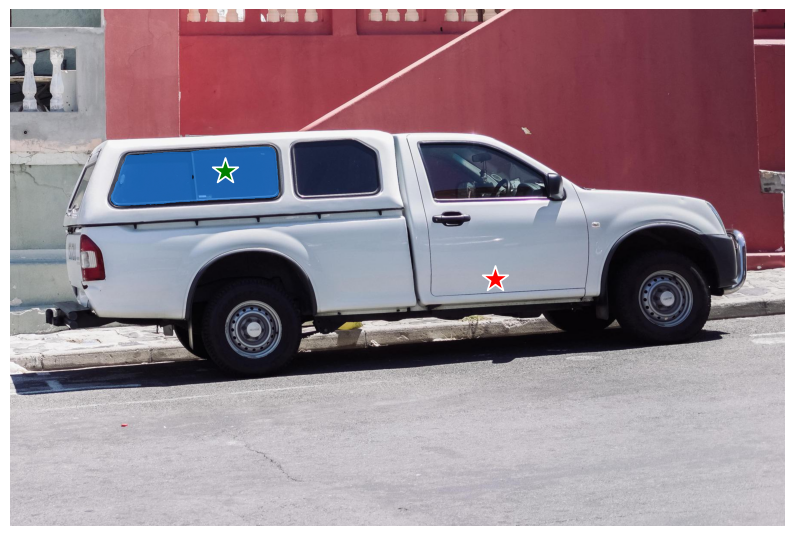

In [67]:
input_point = np.array([[500, 375], [1125, 625]])
input_label = np.array([1, 0])

mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

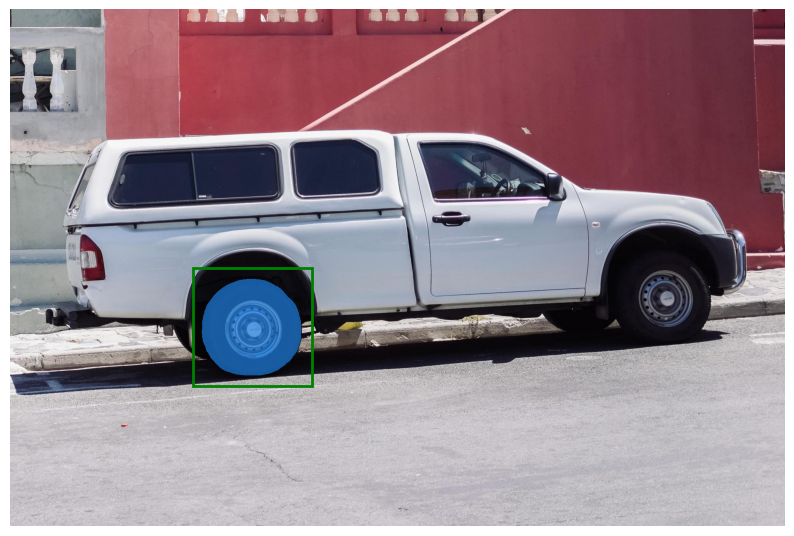

In [68]:
input_box = np.array([425, 600, 700, 875])
masks, _, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=False,
)
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
plt.axis('off')
plt.show()

## 点とボックスの組み合わせ
点とボックスの両方のタイプのプロンプトを予測器に含めるだけで組み合わせることができる

まず、次の画像においてトラックのタイヤのみを選択し、ホイール全体ではなくすることができる


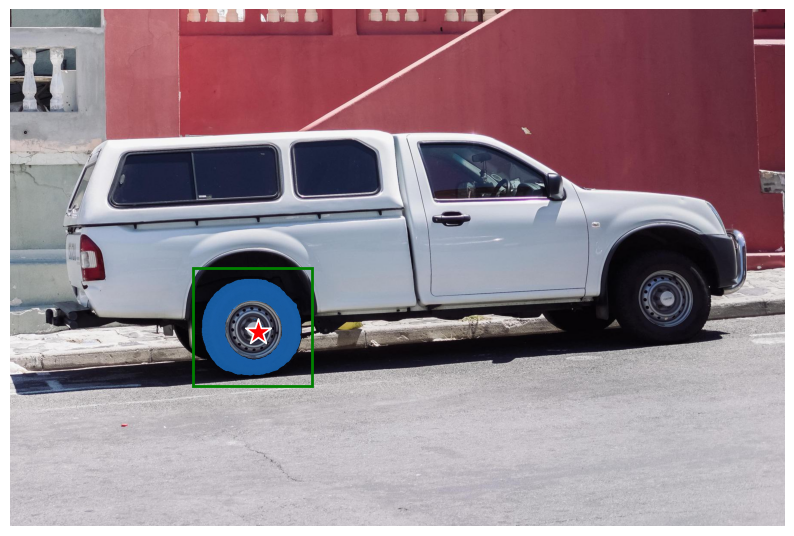

In [69]:
input_box = np.array([425, 600, 700, 875])
input_point = np.array([[575, 750]])
input_label = np.array([0])
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

## バッチ化されたプロンプト入力
SamPredictorは、同じ画像に対して複数の入力プロンプトを受け取ることができる

In [70]:
input_boxes = torch.tensor([
    [75, 275, 1725, 850],
    [425, 600, 700, 875],
    [1375, 550, 1650, 800],
    [1240, 675, 1400, 750],
], device=predictor.device)

In [71]:
transformed_boxes = predictor.transform.apply_boxes_torch(input_boxes, image.shape[:2])
masks, _, _ = predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=transformed_boxes,
    multimask_output=False,
)

In [72]:
masks.shape  # (batch_size) x (num_predicted_masks_per_input) x H x W

torch.Size([4, 1, 1200, 1800])

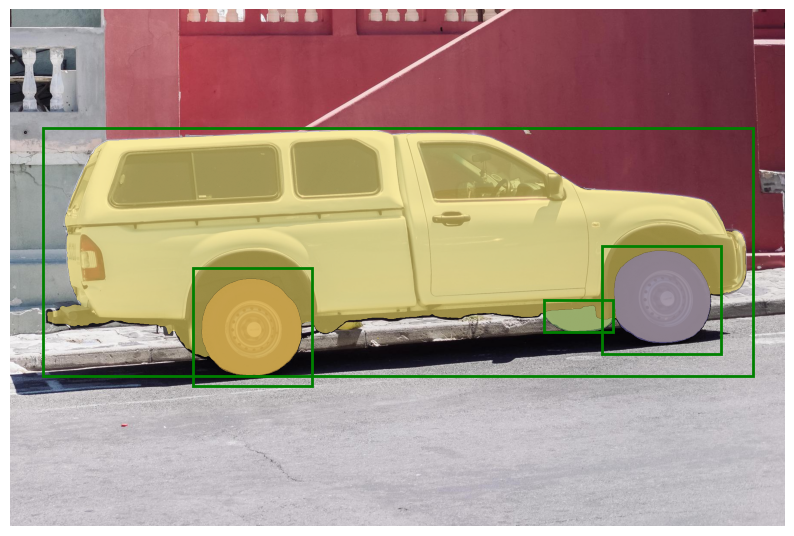

In [73]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
for mask in masks:
    show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)
for box in input_boxes:
    show_box(box.cpu().numpy(), plt.gca())
plt.axis('off')
plt.show()

エンドツーエンドのバッチ推論

すべてのプロンプトが事前に利用可能である場合、SAMをエンドツーエンドの方法で直接実行することができる

したがって、画像間でのバッチ処理も可能である

In [74]:
image1 = image  # truck.jpg from above
image1_boxes = torch.tensor([
    [75, 275, 1725, 850],
    [425, 600, 700, 875],
    [1375, 550, 1650, 800],
    [1240, 675, 1400, 750],
], device=sam.device)

image2 = cv2.imread('images/groceries.jpg')
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
image2_boxes = torch.tensor([
    [450, 170, 520, 350],
    [350, 190, 450, 350],
    [500, 170, 580, 350],
    [580, 170, 640, 350],
], device=sam.device)

画像とプロンプトは、正しいフレームに変換済みのPyTorchテンソルとして入力される
- 入力は画像のリストとしてパッケージ化され、各要素は次のキーを持つ辞書となる
  - image：CHW形式のPyTorchテンソルとしての入力画像
  - original_size：SAMへの入力用に変換する前の画像サイズ（H/W形式）
  - point_coords：バッチ化されたポイントプロンプトの座標
  - point_labels：バッチ化されたポイントプロンプトのラベル
  - boxes：バッチ化された入力ボックス
  - mask_inputs：バッチ化された入力マスクであり、 プロンプトが存在しない場合、キーを除外することができる

In [75]:
from segment_anything.utils.transforms import ResizeLongestSide
resize_transform = ResizeLongestSide(sam.image_encoder.img_size)

def prepare_image(image, transform, device):
    image = transform.apply_image(image)
    image = torch.as_tensor(image, device=device.device)
    return image.permute(2, 0, 1).contiguous()

In [76]:
batched_input = [
     {
         'image': prepare_image(image1, resize_transform, sam),
         'boxes': resize_transform.apply_boxes_torch(image1_boxes, image1.shape[:2]),
         'original_size': image1.shape[:2]
     },
     {
         'image': prepare_image(image2, resize_transform, sam),
         'boxes': resize_transform.apply_boxes_torch(image2_boxes, image2.shape[:2]),
         'original_size': image2.shape[:2]
     }
]

In [77]:
batched_output = sam(batched_input, multimask_output=False)

出力は各入力画像の結果に対するリストであり、リストの要素は次のキーを持つ辞書である

- masks：予測されたバイナリマスクのバッチ化されたtorchテンソルで、オリジナル画像のサイズ
- iou_predictions：各マスクの品質に対するモデルの予測
- low_res_logits：各マスクの低解像度のlogitsで、後の反復でマスク入力としてモデルに渡すことができる

In [78]:
batched_output[0].keys()

dict_keys(['masks', 'iou_predictions', 'low_res_logits'])

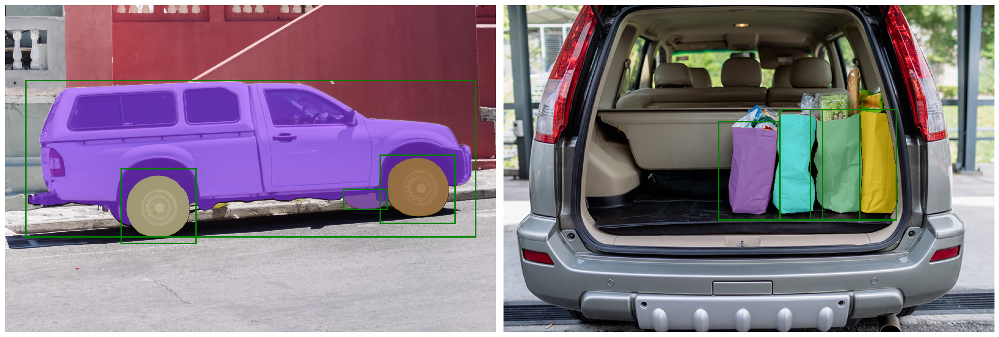

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(20, 20))

ax[0].imshow(image1)
for mask in batched_output[0]['masks']:
    show_mask(mask.cpu().numpy(), ax[0], random_color=True)
for box in image1_boxes:
    show_box(box.cpu().numpy(), ax[0])
ax[0].axis('off')

ax[1].imshow(image2)
for mask in batched_output[1]['masks']:
    show_mask(mask.cpu().numpy(), ax[1], random_color=True)
for box in image2_boxes:
    show_box(box.cpu().numpy(), ax[1])
ax[1].axis('off')

plt.tight_layout()
plt.show()

# 参考文献

- Long, J. et al. (2015). "Fully Convolutional Networks for Semantic Segmentation." CVPR 2015.
- Ronneberger, O. et al. (2015). "U-Net: Convolutional Networks for Biomedical Image Segmentation." MICCAI 2015.
- Badrinarayanan, V. et al. (2017). "SegNet: A Deep Convolutional Encoder-Decoder Architecture for Image Segmentation." IEEE TPAMI.
- Iglovikov, V. & Shvets, A. (2018). "TernausNet: U-Net with VGG11 Encoder Pre-Trained on ImageNet for Image Segmentation." arXiv:1801.05746.
- Chen, L.-C. et al. (2018). "Encoder-Decoder with Atrous Separable Convolution for Semantic Image Segmentation." ECCV 2018.
- Kirillov, A. et al. (2023). "Segment Anything." ICCV 2023.
- Ravi, N. et al. (2024). "SAM 2: Segment Anything in Images and Videos." arXiv:2408.00714.